<a href="https://colab.research.google.com/github/TunaStark/ITO-ML-DL-Examples/blob/master/Deep_Learning/LSTM_Example_DL_ITO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q yfinance

import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

hisse = 'TSLA'
df = yf.download(hisse, start='2020-01-01', end='2026-05-20')
data = df['Close'].values.reshape(-1, 1)

print(f"{hisse} verisi başarıyla çekildi. Toplam gün sayısı: {len(data)}")

/tmp/ipykernel_16198/2090801816.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(hisse, start='2020-01-01', end='2026-05-20')
[*********************100%***********************]  1 of 1 completed

TSLA verisi başarıyla çekildi. Toplam gün sayısı: 1603


In [6]:
egitim_veri_uzunlugu = int(np.ceil(len(data) * .8))

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

train_data = scaled_data[0:int(egitim_veri_uzunlugu), :]
x_train, y_train = [], []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("Eğitim verisi LSTM formatına (3 boyutlu) dönüştürüldü.")

Eğitim verisi LSTM formatına (3 boyutlu) dönüştürüldü.


In [7]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

erken_durma = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_dusurucu = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

print("Eğitim başlıyor...")
history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.1,
    callbacks=[erken_durma, lr_dusurucu]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Eğitim başlıyor...
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - loss: 0.0193 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.0034 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0029 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0027 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0025 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0023 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0022 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - loss: 0.0020 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0019 - val_loss: 0.0040 - learning_rate: 0.

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Hata Oranı (RMSE): 19.562905765336712


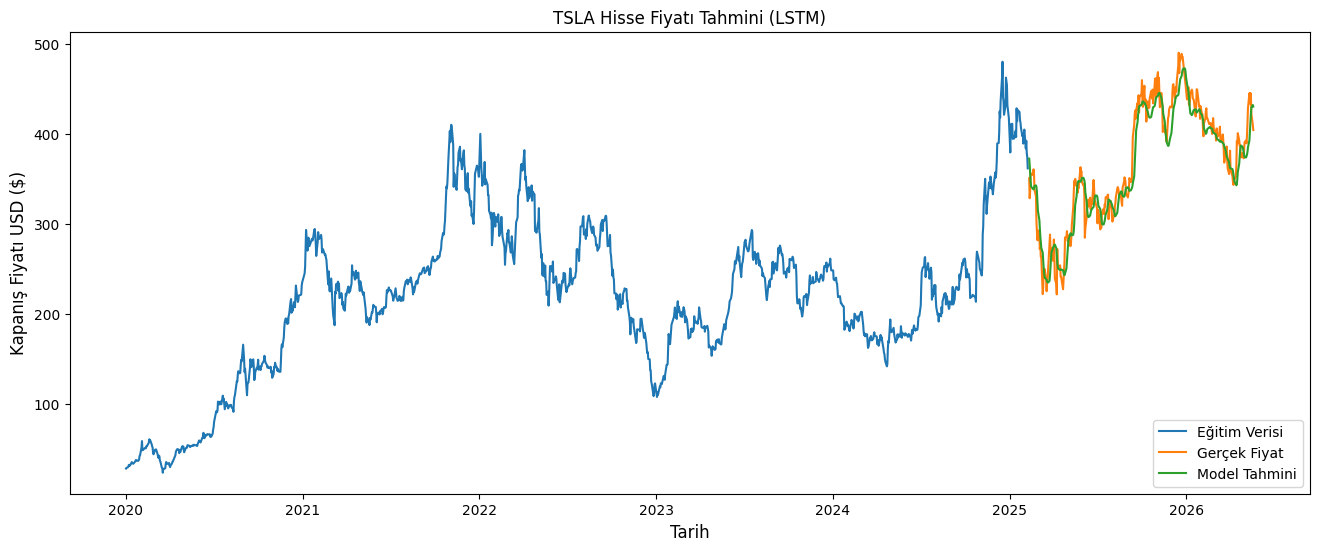

In [8]:
test_data = scaled_data[egitim_veri_uzunlugu - 60: , :]
x_test = []
y_test = data[egitim_veri_uzunlugu:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

tahminler = model.predict(x_test)
tahminler = scaler.inverse_transform(tahminler)

rmse = np.sqrt(np.mean(((tahminler - y_test) ** 2)))
print(f"Hata Oranı (RMSE): {rmse}")

train = df[:egitim_veri_uzunlugu].copy()
valid = df[egitim_veri_uzunlugu:].copy()
valid['Tahminler'] = tahminler

plt.figure(figsize=(16,6))
plt.title(f'{hisse} Hisse Fiyatı Tahmini (LSTM)')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Kapanış Fiyatı USD ($)', fontsize=12)
plt.plot(train.index, train['Close'])
plt.plot(valid.index, valid[['Close', 'Tahminler']])
plt.legend(['Eğitim Verisi', 'Gerçek Fiyat', 'Model Tahmini'], loc='lower right')
plt.show()